In [7]:
import os
import pickle
import matplotlib.pyplot as plt
import sys
import pandas as pd
internal_PDC_data_dir = os.getcwd()
internal_VTR_dir = os.path.abspath(os.path.join(internal_PDC_data_dir, '..', '..'))
root_dir = os.path.abspath(os.path.join(internal_VTR_dir, '..'))
internal_HT_dir = os.path.abspath(os.path.join(root_dir, '8_Hardware', 'Hardware_Testing'))
internal_HT_PDC_dir = os.path.abspath(os.path.join(internal_HT_dir, '1_PD_Controllers'))
internal_scripts_dir = os.path.abspath(os.path.join(internal_HT_PDC_dir, 'scripts'))
sys.path.append(internal_scripts_dir)
import H_Common_Params as CP

In [8]:
internal_CDP_data_dir = os.path.abspath(os.path.join(internal_PDC_data_dir, 'Collected_Data_Python'))
print(internal_CDP_data_dir)

d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\Vehicle_Testing_Results\April_21\Pd_controller_data\Collected_Data_Python


In [9]:
data_list = []
for i in range(len(os.listdir(internal_CDP_data_dir))):
    data_list.append(pd.read_csv(os.path.join(internal_CDP_data_dir, os.listdir(internal_CDP_data_dir)[i])))

In [10]:
data_list[-1].head()

,Ego_Position(m),Ego_Velocity(m/s),Time(s)
0,0.0,0.0,0.000022
1,0.0,0.0,0.069183
2,0.0,0.0,0.178611
3,0.0,0.0,0.288899
4,0.0,0.0,0.398987


In [17]:
def plot(separations, velocities, times = None, Dr = CP.Dr_3, Vp = CP.Vp_3):
    font = 50
    if times is None:
        times = [0.1 * i for i in range(len(separations))]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (60, 25))
    
    plot_separations = [Dr - x for x in separations]
    
    ax1.plot(times, plot_separations, linewidth = 4)
    ax1.plot(times, [CP.Dd + CP.Td * Vp for _ in range(len(plot_separations))], label = f'Desired final seperation', color = 'green', linewidth = 6)
    ax1.grid(True, linewidth = 4)
    ax1.set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    ax1.set_ylabel('Separation [m]', fontsize = font, fontweight = 'bold')
    ax1.set_title(f'[Dr = {Dr}m , Vp = {round(Vp * 18 / 5, 2)}km/hr', fontsize = font, fontweight = 'bold')
    ax1.tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    ax1.legend(fontsize = font)
    
    ax2.plot(times, velocities)
    ax2.plot(times, [Vp * 18 / 5 for _ in range(len(velocities))], label = f'Desired final velocity', color = 'green', linewidth = 6)
    ax2.grid(True, linewidth = 4)
    ax2.set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    ax2.set_ylabel('Velocity [km/hr]', fontsize = font, fontweight = 'bold')
    ax2.set_title(f'[Dr = {Dr}m , Vp = {round(Vp * 18 / 5, 2)}km/hr', fontsize = font, fontweight = 'bold')
    ax2.tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    ax2.legend(fontsize = font)
    
    plt.show()

In [18]:
print(list(data_list[0]['Time(s)']))

[1.955e-05, 0.009035826, 0.121897221, 0.230890751, 0.340670347, 0.450378418, 0.561395645, 0.670584202, 0.781574249, 0.890603066, 1.001422882, 1.110641956, 1.22142911, 1.330731869, 1.441287994, 1.550575018, 1.661340475, 1.772602797, 1.881565809, 1.990438461, 2.100771666, 2.211058855, 2.321290731, 2.430494785, 2.541800499, 2.650432825, 2.761184216, 2.870390177, 2.981590748, 3.090551853, 3.201852083, 3.310652494, 3.42086339, 3.531116962, 3.640762806, 3.751636982, 3.86151576, 3.970672607, 4.081846237, 4.191520691, 4.301723719, 4.409883738, 4.521597624, 4.630824328, 4.741694212, 4.850688934, 4.961509943, 5.071430683, 5.181775332, 5.290566683, 5.401681662, 5.510490179, 5.620948076, 5.730644465, 5.842017174, 5.952221394, 6.061177731, 6.169923306, 6.281205893, 6.390402317, 6.5018699170000005, 6.610652685, 6.721927404, 6.830910683, 6.941886902, 7.05171442, 7.161519289, 7.271300793, 7.38124609, 7.491969585, 7.601532698, 7.710716724, 7.821329117, 7.930646658, 8.041051865, 8.151828766, 8.261506319

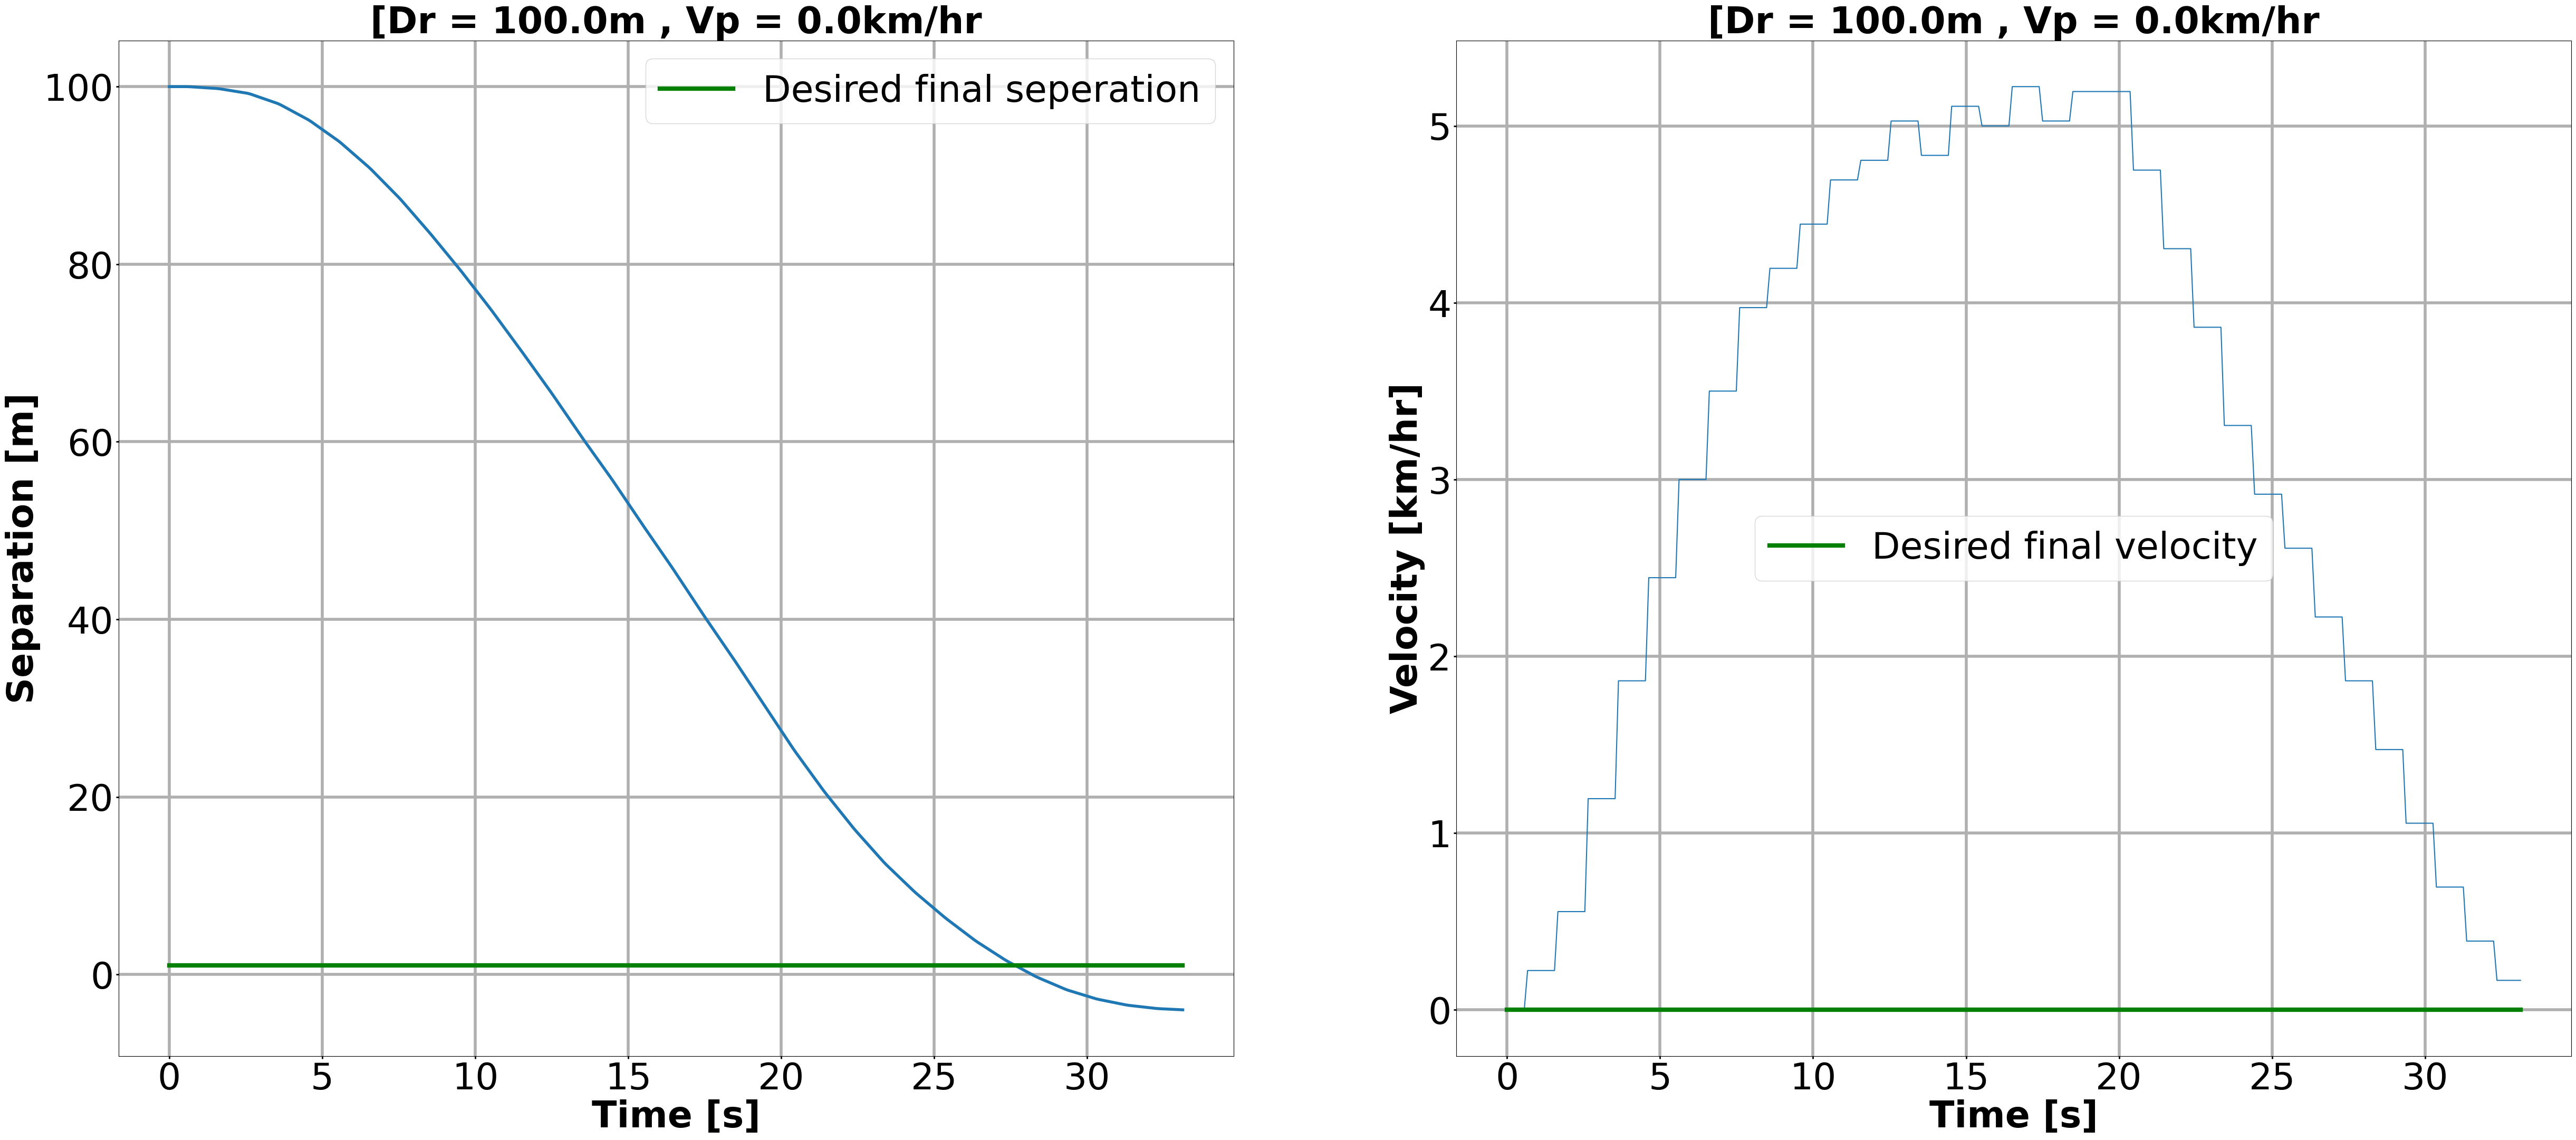

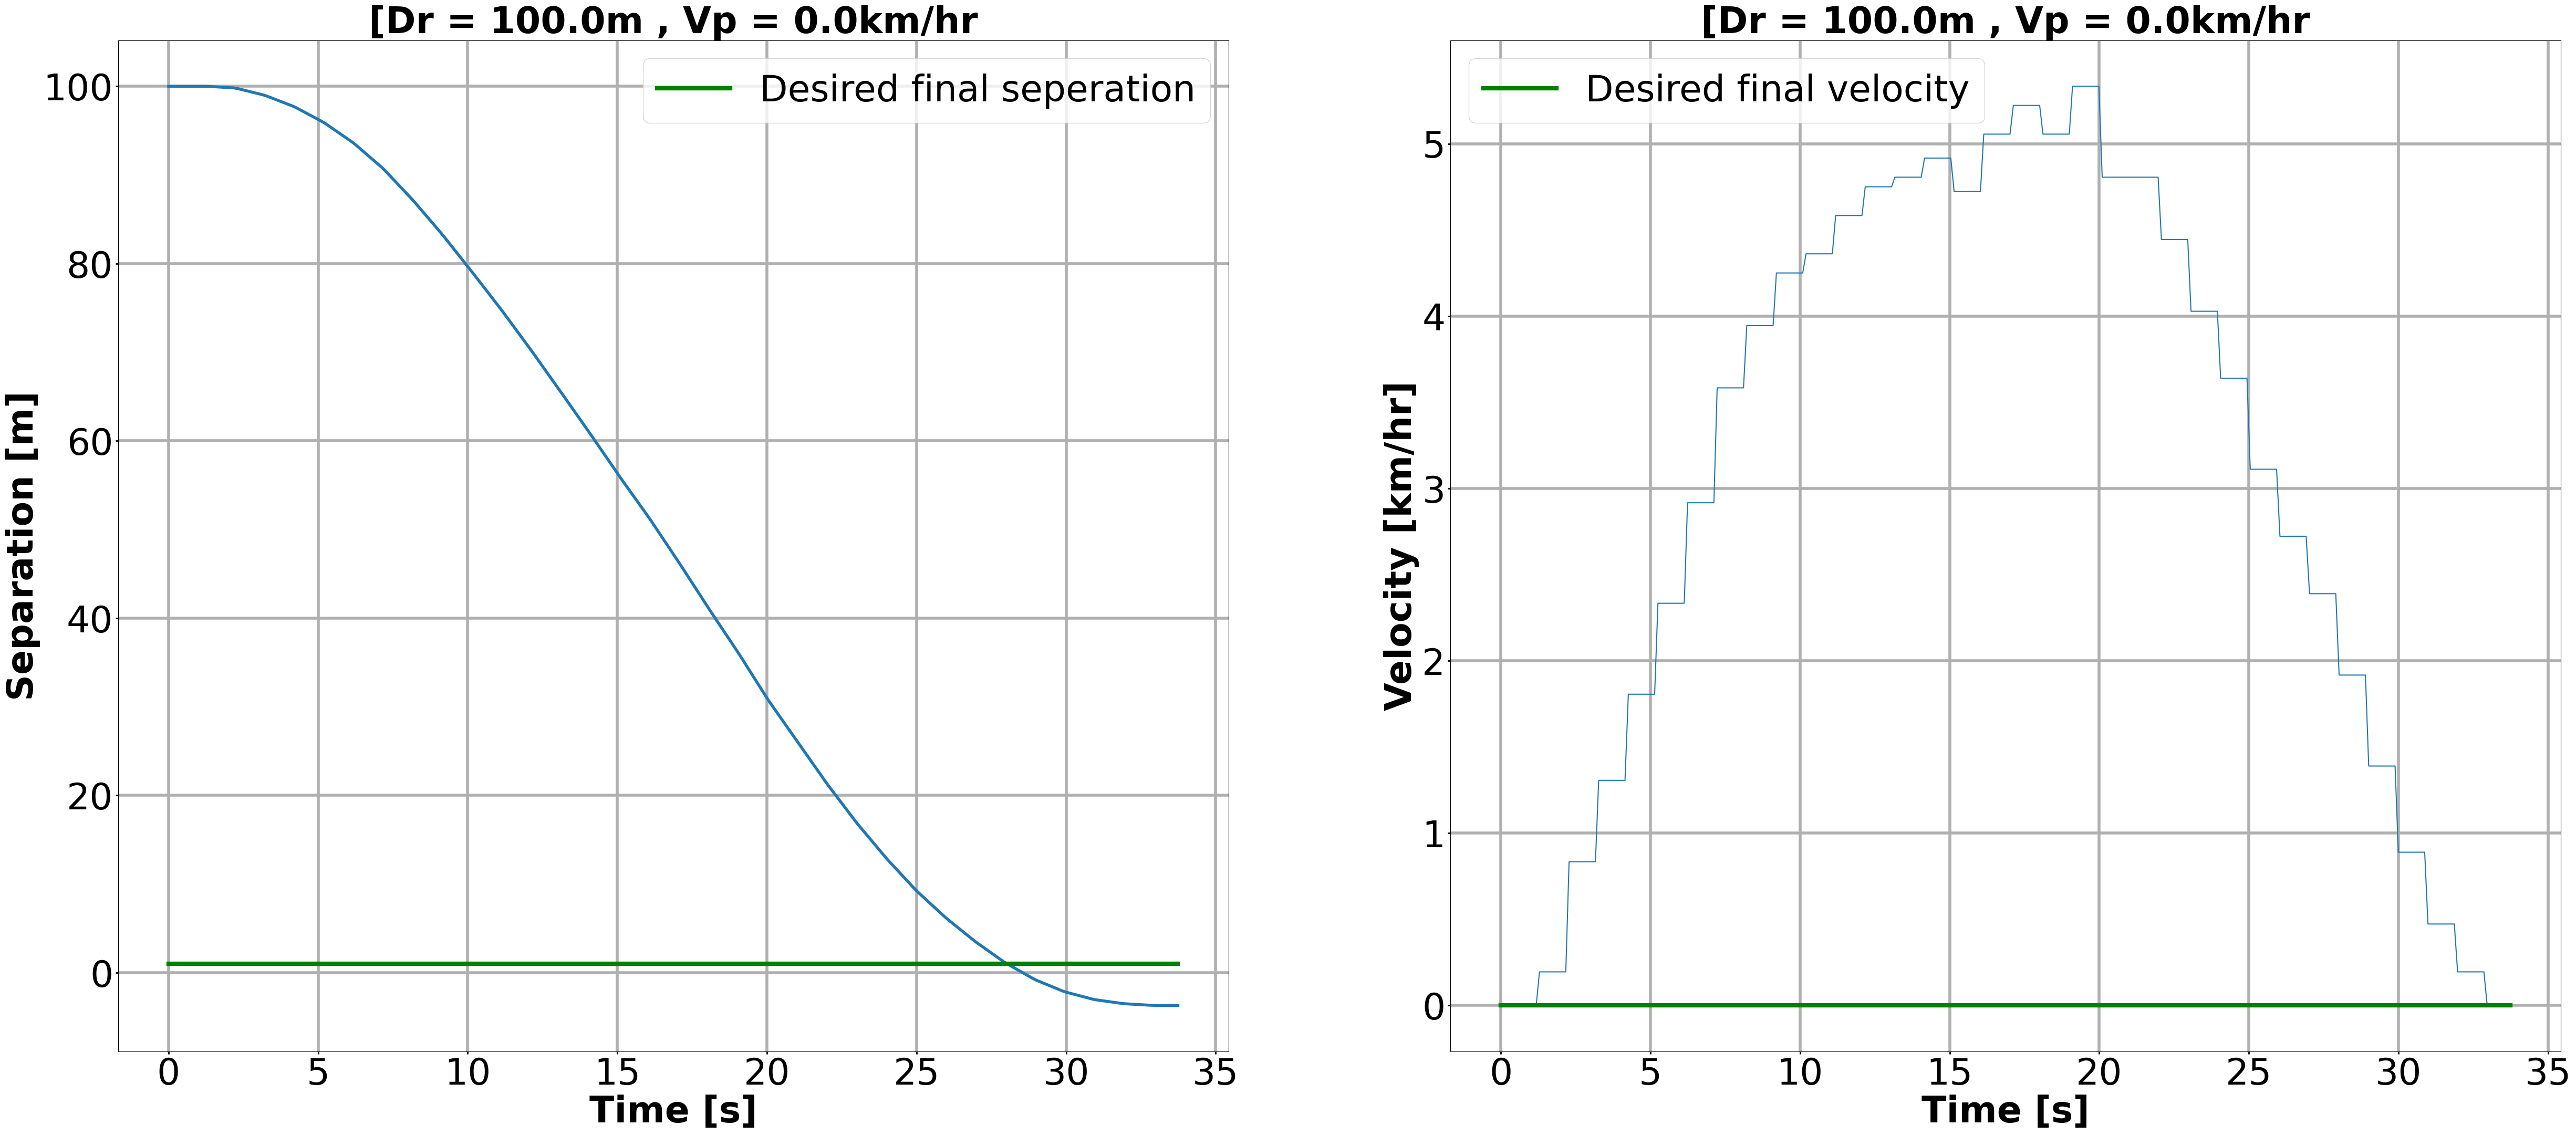

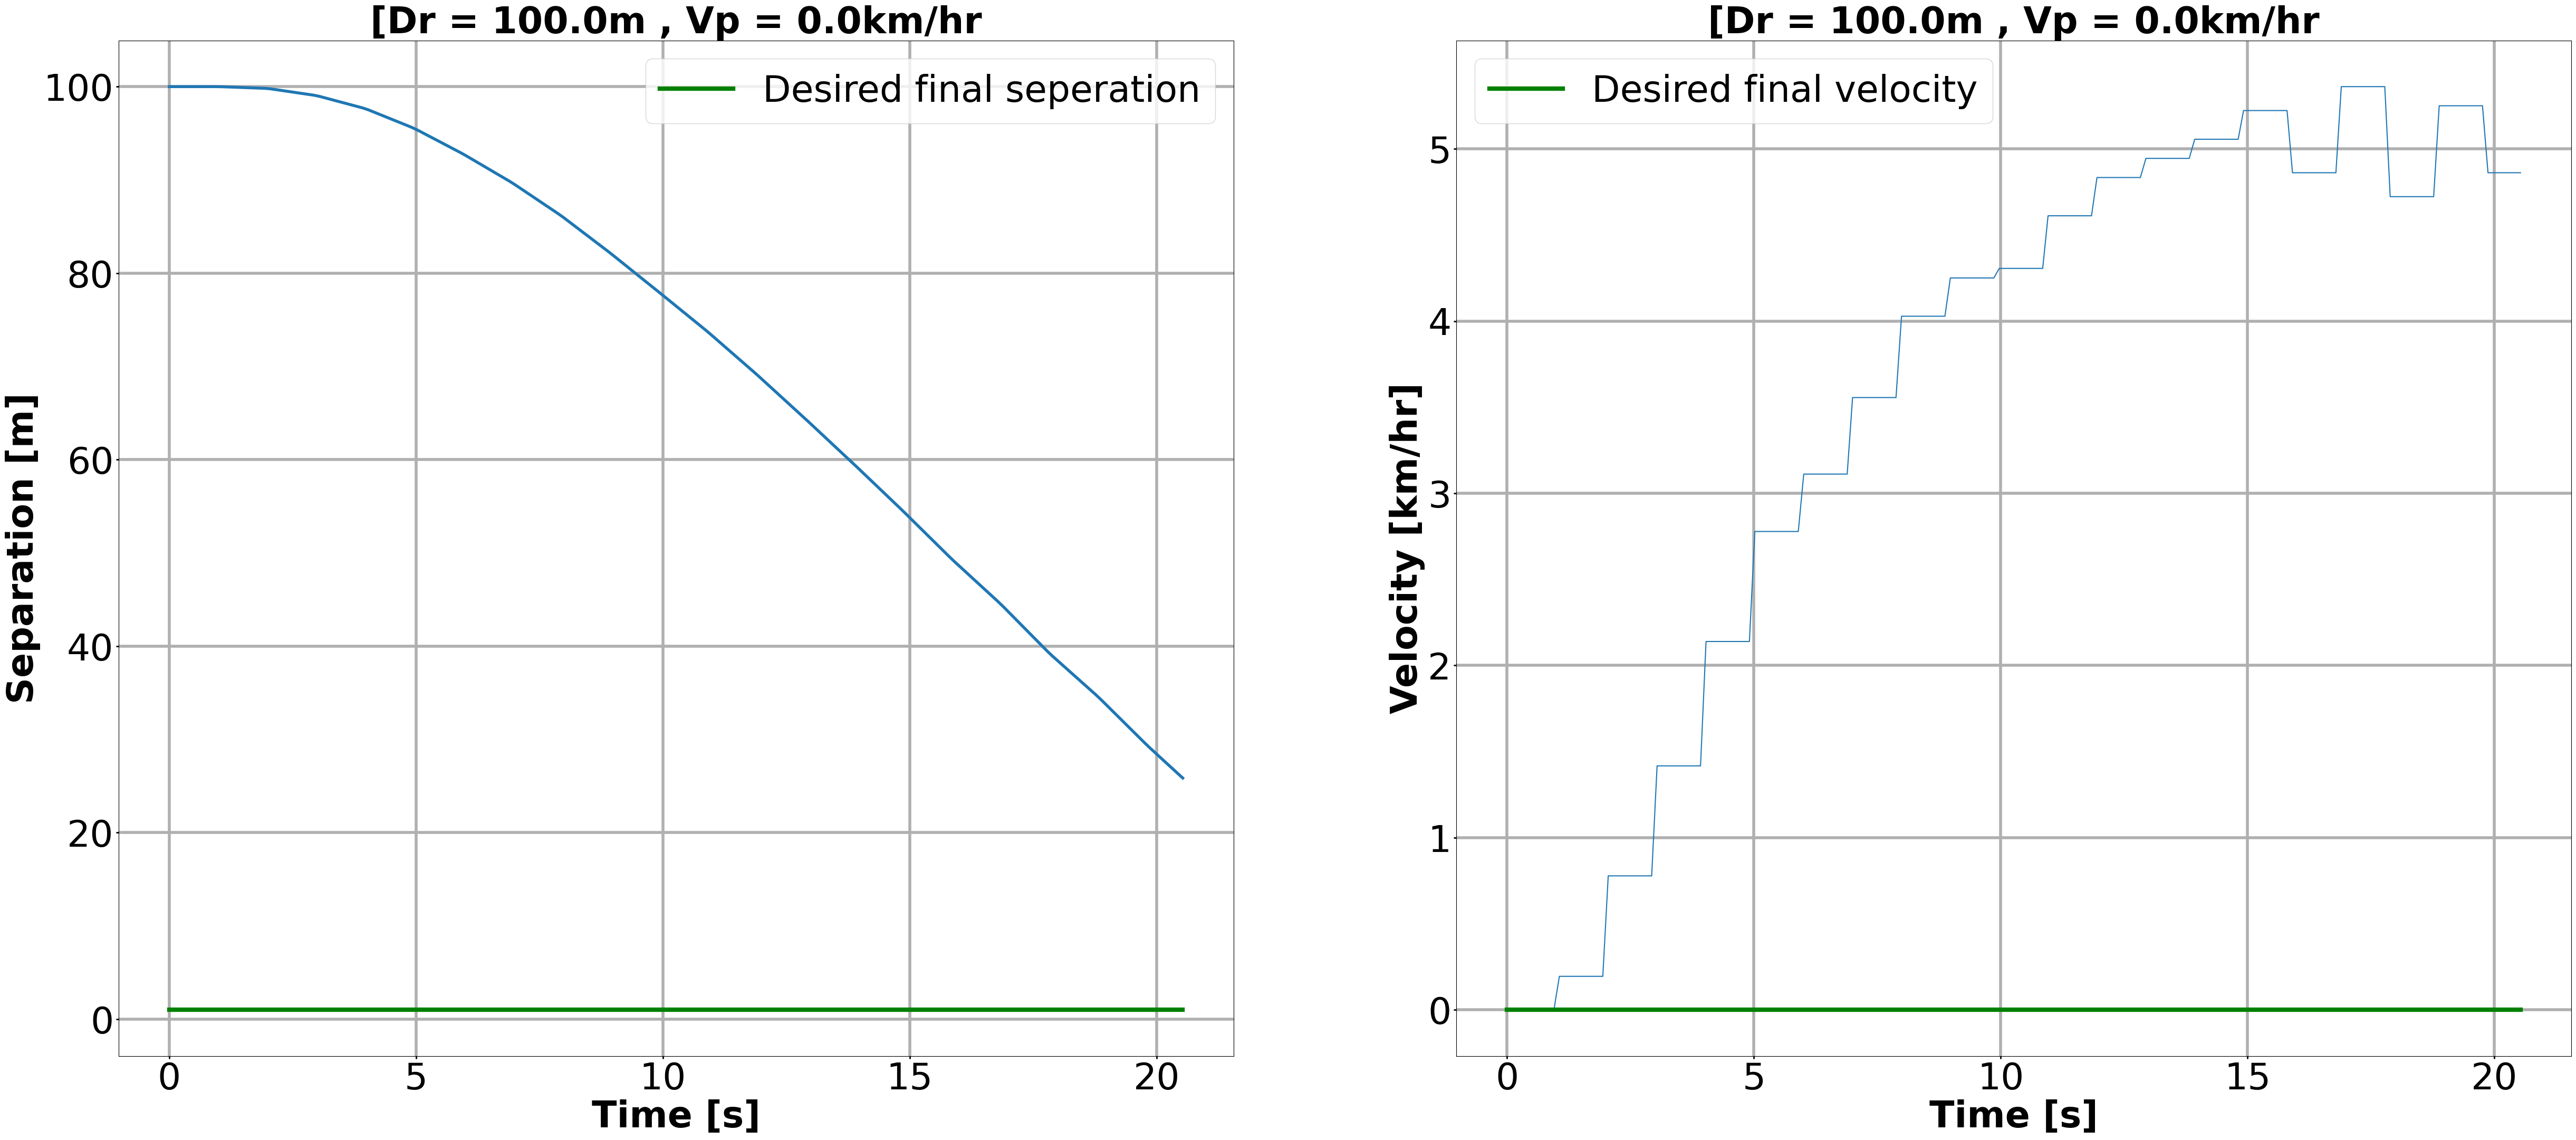

In [19]:
for i in range(len(data_list)):
    plot(list(data_list[i]['Ego_Position(m)']), list(data_list[i]['Ego_Velocity(m/s)']), list(data_list[i]['Time(s)']))

In [21]:
print(list(data_list[-1]['Ego_Velocity(m/s)']))
print(list(data_list[-1]['Time(s)']))

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1944444411330753, 0.1944444411330753, 0.1944444411330753, 0.1944444411330753, 0.1944444411330753, 0.1944444411330753, 0.1944444411330753, 0.1944444411330753, 0.1944444411330753, 0.7777777645323012, 0.7777777645323012, 0.7777777645323012, 0.7777777645323012, 0.7777777645323012, 0.7777777645323012, 0.7777777645323012, 0.7777777645323012, 0.7777777645323012, 1.4166666401757135, 1.4166666401757135, 1.4166666401757135, 1.4166666401757135, 1.4166666401757135, 1.4166666401757135, 1.4166666401757135, 1.4166666401757135, 1.4166666401757135, 2.1388889683617487, 2.1388889683617487, 2.1388889683617487, 2.1388889683617487, 2.1388889683617487, 2.1388889683617487, 2.1388889683617487, 2.1388889683617487, 2.1388889683617487, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 3.1111110581292047, 3.1111110581292047, 3.1111110